# 🏨 Assignment 1 (based on Hotel Booking Demand Dataset)
**Author:** Emad Firoozi

**Course:** Applied Data Science

**Date:** 5/2/2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1b2NnHOm52CeE68JkQC225A5vP9ZD1suW?usp=sharing)
[![View on GitHub](https://img.shields.io/badge/GitHub-View_Repository-blue?logo=github)](https://github.com/firooziemad/Applied-Data-Science-course)

---

## Dataset Selection: Hotel Booking Demand

**Source:** [Kaggle - Hotel Booking Demand (Jesse Mostipak)](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

For this project, I have chosen the **Hotel Booking Demand** dataset. This is a real-world, industry-standard dataset containing booking records for a city hotel and a resort hotel.

### Why this dataset?
This dataset was selected because it perfectly aligns with all project requirements:

*   **Real-World Data Cleaning:** It contains organic missing values (e.g., in `company`, `agent`, and `country` columns) and data anomalies (e.g., bookings with zero guests) that require standard preprocessing and imputation techniques.
*   **Diverse Visualizations:** It features a mix of categorical, numerical, and temporal data, allowing for meaningful exploration through box plots, multi-line charts, and scatter plots.
*   **Feature Engineering Potential:** The dataset provides clear opportunities to engineer new features, such as aggregating total stay durations, calculating price-per-person ratios, and transforming arrival dates into usable datetime formats.

### Dataset Overview
*   **Observations:** ~119,390 rows (individual bookings)
*   **Features:** 32 columns (including booking lead time, length of stay, average daily rate, and guest demographics)
*   **Target Variable:** `is_canceled` (Binary: 0 = Not Canceled, 1 = Canceled)

# Part 1: Exploratory Data Analysis & Data Cleaning
In this section, we will load the Hotel Booking Demand dataset, explore its features, identify missing or invalid data, and preprocess it for machine learning models.

Our goals are to:
1. Understand the distributions and correlations of our features.
2. Clean missing values, drop duplicates, and handle invalid entries.
3. Encode categorical variables and scale numerical features.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import io

# Visual settings
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings('ignore')

# File upload
from google.colab import files
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [ ]:
# Load the dataset
df = pd.read_csv(io.BytesIO(uploaded['hotel_bookings.csv']))

# The dataset uses the string 'NULL' for missing values in some columns. We must convert these to actual NaN values first for Pandas to recognize them.
df.replace('NULL', np.nan, inplace=True)

print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


### 1.1 Comprehensive Exploratory Data Analysis (EDA) with meaningful insights
First, let's understand the data types and look at the basic statistics of our numerical columns.

In [ ]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Statistical summary of numerical columns
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Let's visualize some key aspects of our data.
First, let's look at the distribution of Market Segments to see where our bookings are coming from.

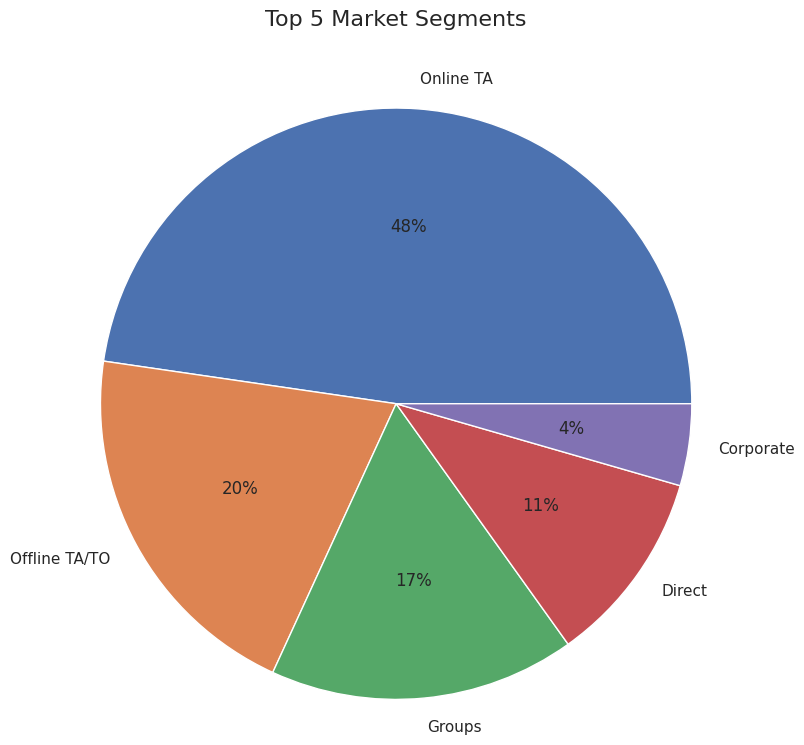

In [ ]:
# Pie chart of Market Segments
plt.figure(figsize=(8, 8))
df['market_segment'].value_counts()[0:5].plot.pie(autopct='%1.0f%%', radius=1.2, ylabel='')
plt.title('Top 5 Market Segments', y=1.1, fontsize=16)
plt.show()

Next, let's look at the relationship between the Average Daily Rate (ADR) and the Customer Type using a bar chart.

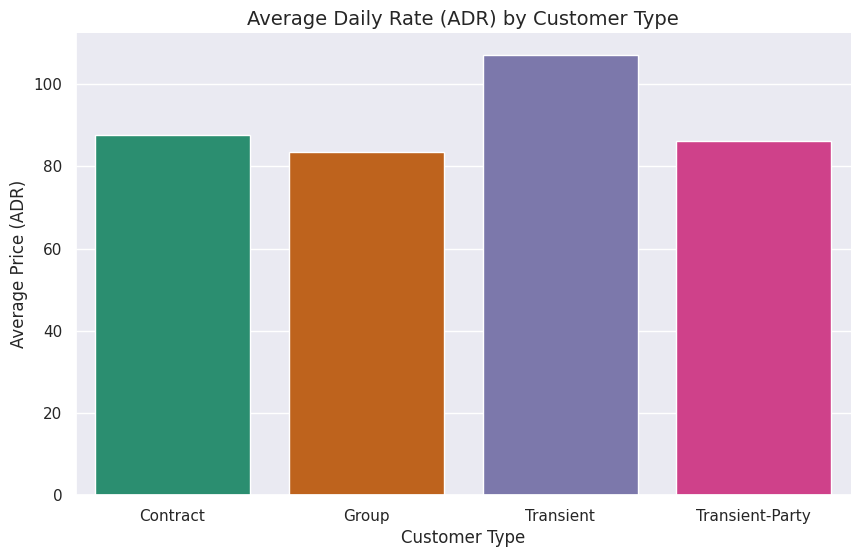

In [ ]:
# Bar chart of average ADR by Customer Type
df_grouped = df.groupby(['customer_type'])['adr'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='customer_type', y='adr', data=df_grouped, palette='Dark2')
plt.title('Average Daily Rate (ADR) by Customer Type', fontsize=14)
plt.xlabel('Customer Type')
plt.ylabel('Average Price (ADR)')
sns.despine()
plt.show()

### 1.2 Data Cleaning
Data cleaning is critical. We need to handle missing values, drop invalid rows, handle outliers, and remove duplicates.

Instead of just looking at raw counts of missing values, let's create a quick "Data Quality Report" function to show the *percentage* of missing data. This helps us make better decisions about whether to drop a column or impute the data.

In [ ]:
# Data Quality Report Function
def missing_data_report(dataframe):
    total_missing = dataframe.isnull().sum().sort_values(ascending=False)
    percent_missing = (dataframe.isnull().sum() / dataframe.isnull().count() * 100).sort_values(ascending=False)
    missing_data = pd.concat([total_missing, percent_missing], axis=1, keys=['Total Missing', 'Percent (%)'])
    return missing_data[missing_data['Total Missing'] > 0]

missing_data_report(df)

,Total Missing,Percent (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


#### Handling Missing Values
Based on our report:
* `company` is missing in almost all rows. we will drop this column entirely.
* `agent` has a significant amount of missing data. We will fill missing values with `0` (indicating no agent).
* `country` has a few missing values. We will fill these with the mode (most frequent country).

In [ ]:
# 1. Drop the 'company' column
if 'company' in df.columns:
    df.drop(['company'], axis=1, inplace=True)

# 2. Fill missing 'agent' with 0 (No agent)
df['agent'].fillna(0, inplace=True)

# 3. Fill missing 'country' with the mode (most frequent)
df['country'].fillna(df['country'].mode()[0], inplace=True)

# Drop any remaining rows with missing values to be safe
df.dropna(inplace=True)
print(f"Shape after handling missing values: {df.shape}")

Shape after handling missing values: (119386, 31)


#### Dealing with Invalid Values
If a booking has 0 adults, 0 children, and 0 babies, it is not a valid hotel booking. These are anomalies in the dataset. Let's filter them out.

In [ ]:
# Find and drop invalid bookings (0 total guests)
invalid_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(f"Found {len(invalid_guests)} invalid rows with 0 guests. Dropping them.")

df.drop(invalid_guests.index, inplace=True)

Found 180 invalid rows with 0 guests. Dropping them.


#### Dealing with Outliers
Let's check the `adr` (Average Daily Rate / Price) for outliers. We will use the quantile-based approach (IQR) to remove extremely high or negative prices to help our future models generalize better.

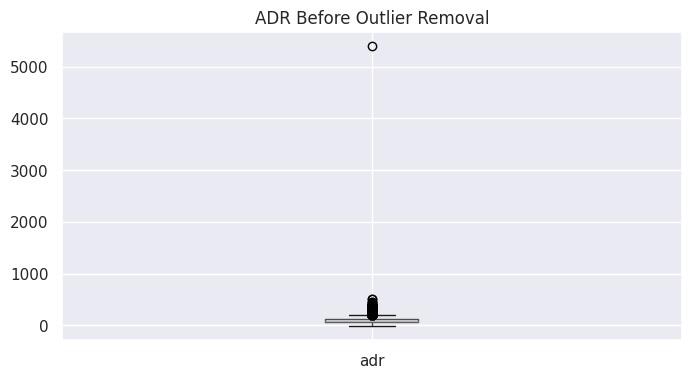

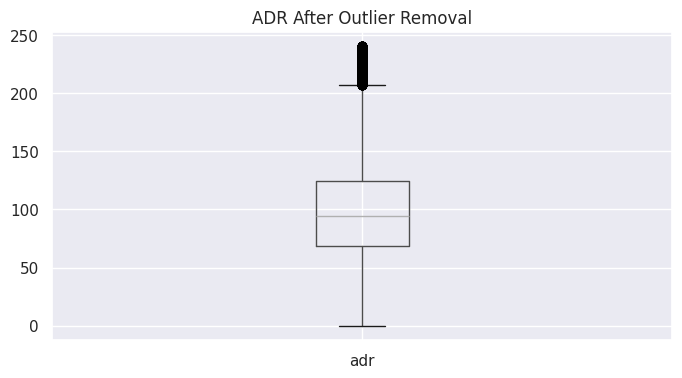

In [ ]:
# Look at the boxplot before cleaning
plt.figure(figsize=(8,4))
df.boxplot(column=['adr'])
plt.title("ADR Before Outlier Removal")
plt.show()

# Remove outliers using the IQR method (0.2 and 0.8 quantiles)
col = ['adr']
Q1 = df[col].quantile(0.2)
Q4 = df[col].quantile(0.8)
IQR = Q4 - Q1

# Keep rows within the accepted range AND drop negative ADR (impossible price)
df = df[~((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q4 + 1.5 * IQR))).any(axis=1)]
df = df[df['adr'] >= 0]

# Look at the boxplot after cleaning
plt.figure(figsize=(8,4))
df.boxplot(column=['adr'])
plt.title("ADR After Outlier Removal")
plt.show()

#### Dealing with Duplicate Data
Finally, we check for and remove exact duplicate rows to prevent our models from overfitting to repeated entries.

In [ ]:
print(f"Duplicate rows found: {df[df.duplicated()].shape[0]}")
df = df.drop_duplicates()
print(f"Shape after data cleaning: {df.shape}")

Duplicate rows found: 31962
Shape after data cleaning: (85554, 31)


#### Dropping Leaky Features
The column `reservation_status` perfectly predicts our target variable (`is_canceled`). Keeping it would cause "data leakage" and ruin our future predictive models, so we must drop it. We will also drop `arrival_date_year` as it is not useful for predicting future patterns.

In [ ]:
# Drop leaky and unnecessary columns
columns_to_drop = ['reservation_status']
# If the one-hot encoded versions exist, drop those instead:
cols_in_df = [col for col in df.columns if 'reservation_status_' in col and col != 'reservation_status_date']
if cols_in_df:
    df.drop(cols_in_df, axis=1, inplace=True)
elif 'reservation_status' in df.columns:
    df.drop(['reservation_status'], axis=1, inplace=True)

### 1.3 Data Preprocessing
Machine learning algorithms require numerical data. We will convert our categorical columns into numerical formats.

Following the lab's instructions:
* **Categorical Encoding:** We will use this for columns with many unique values (like `country` or dates).
* **One-Hot-Encoding:** We will use this for columns with a limited range of unique categories (like `meal`, `market_segment`).

In [ ]:
# 1. Categorical Encoding (for high cardinality features)
to_categorical_columns = ['country', 'reservation_status_date']

for column in to_categorical_columns:
    if column in df.columns:
        df[column] = df[column].astype('category').cat.codes

# 2. One-Hot-Encoding (for low cardinality features)
to_one_hot_columns = df.select_dtypes(include=["object"]).columns

for column in to_one_hot_columns:
    encoded_df = pd.get_dummies(df[column], prefix=column)
    df = pd.concat([df, encoded_df], axis=1) # Safer alternative to the lab's direct assignment

# Drop the original non-numerical columns since they are now encoded
df.drop(to_one_hot_columns, axis=1, inplace=True)

# Verify all columns are numeric
print(df.select_dtypes(include=["object"]).columns) # check empty

Index([], dtype='object')


### 1.4 Normalization and Standardization
To ensure features with larger scales don't dominate our analysis, we scale the data.
* **StandardScaler** (0-mean, standard deviation of 1) will be used for continuous variables with wider ranges.
* **MinMaxScaler** (values mapped between 0 and 1) will be used for discrete counts (like days or number of people).

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standard Scaling
scaler_std = StandardScaler()
standard_scaling_columns = ['adr', 'days_in_waiting_list']

# MinMax Scaling
scaler_minmax = MinMaxScaler()
minmax_scaling_columns = ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'booking_changes']

# Apply scalers
df[standard_scaling_columns] = scaler_std.fit_transform(df[standard_scaling_columns])
df[minmax_scaling_columns] = scaler_minmax.fit_transform(df[minmax_scaling_columns])

# Check the results of Standard Scaler
df[standard_scaling_columns].describe().round(2)

,adr,days_in_waiting_list
count,85554.00,85554.00
mean,-0.00,-0.00
std,1.00,1.00
min,-2.21,-0.08
25%,-0.67,-0.08
50%,-0.13,-0.08
75%,0.59,-0.08
max,2.95,38.71


### 1.5 Correlation Analysis
Finally, we check the correlation matrix. This helps identify linearly dependent columns. If two features are highly correlated (e.g., close to 1.0), we might want to drop one during the feature engineering phase to reduce dimensionality.

In [ ]:
# Calculate correlation on a subset of important features to keep the visual readable
subset_cols = ['is_canceled', 'adr', 'days_in_waiting_list', 'stays_in_week_nights',
               'stays_in_weekend_nights', 'adults', 'children', 'booking_changes',
               'previous_cancellations']

corr = df[subset_cols].corr()
corr.style.background_gradient(cmap='coolwarm')

,is_canceled,adr,days_in_waiting_list,stays_in_week_nights,stays_in_weekend_nights,adults,children,booking_changes,previous_cancellations
is_canceled,1.000000,0.135381,0.005307,0.081835,0.058296,0.080464,0.059583,-0.092305,0.052231
adr,0.135381,1.000000,-0.035037,0.051622,0.037798,0.253074,0.282481,-0.002925,-0.054576
days_in_waiting_list,0.005307,-0.035037,1.000000,0.002275,-0.031771,-0.014443,-0.019168,0.024906,0.003660
stays_in_week_nights,0.081835,0.051622,0.002275,1.000000,0.550818,0.099059,0.027031,0.066245,-0.018528
stays_in_weekend_nights,0.058296,0.037798,-0.031771,0.550818,1.000000,0.091527,0.025703,0.033517,-0.020526
adults,0.080464,0.253074,-0.014443,0.099059,0.091527,1.000000,0.011975,-0.039475,-0.041972
children,0.059583,0.282481,-0.019168,0.027031,0.025703,0.011975,1.000000,0.033351,-0.017955
booking_changes,-0.092305,-0.002925,0.024906,0.066245,0.033517,-0.039475,0.033351,1.000000,-0.010112
previous_cancellations,0.052231,-0.054576,0.003660,-0.018528,-0.020526,-0.041972,-0.017955,-0.010112,1.000000


# Part 2: Data Visualization
In this section, we will practice various visualization techniques to uncover insights from our hotel booking data.

**Note on Best Practices:** Because we scaled and encoded our main dataframe (`df`) for machine learning in Part 1, we will create a quick visualization copy (`df_viz`) from our cleaned data before encoding. This ensures our charts have human-readable axis labels (like actual prices in dollars and actual month names) rather than scaled decimals.

In [ ]:
# Create a fresh, clean dataframe specifically for readable visualizations
df_viz = pd.read_csv(io.BytesIO(uploaded['hotel_bookings.csv']))
df_viz.replace(['NULL', '   NULL'], np.nan, inplace=True)
df_viz.dropna(subset=['country'], inplace=True) # Basic cleaning for viz
df_viz['agent'].fillna(0, inplace=True)
df_viz = df_viz[(df_viz['adults'] > 0) | (df_viz['children'] > 0)] # Drop invalid
df_viz = df_viz[df_viz['adr'] >= 0] # Drop negative prices
df_viz = df_viz[df_viz['adr'] < 1000] # Drop extreme outlier for cleaner charts

# Setup plotting style
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

### 2.1 Pie Charts and Box Plots
**Goal:** Understand the overall composition of hotel types and the distribution of prices.

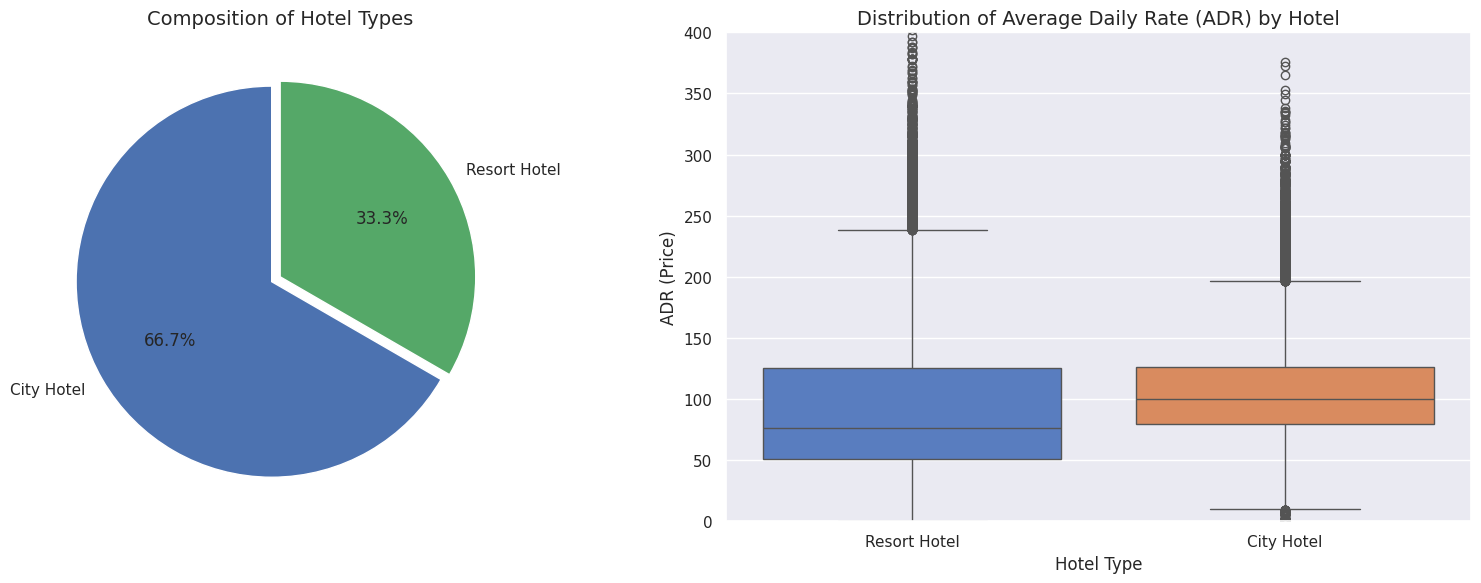

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Pie Chart: Composition of Hotel Types
hotel_counts = df_viz['hotel'].value_counts()
axes[0].pie(hotel_counts, labels=hotel_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#55A868'], startangle=90, explode=(0.05, 0))
axes[0].set_title('Composition of Hotel Types', fontsize=14)

# 2. Box Plot: Distribution of ADR (Price) by Hotel Type
sns.boxplot(ax=axes[1], x='hotel', y='adr', data=df_viz, palette="muted")
axes[1].set_title('Distribution of Average Daily Rate (ADR) by Hotel', fontsize=14)
axes[1].set_xlabel('Hotel Type', fontsize=12)
axes[1].set_ylabel('ADR (Price)', fontsize=12)
axes[1].set_ylim(0, 400) # Setting a logical y-axis range

plt.tight_layout()
plt.show()

### 2.2 Line Charts and Multi-Line Charts
**Goal:** Observe the seasonality of hotel prices.

*Creative Touch:* By default, Python sorts text alphabetically (April, August, December...). We will programmatically sort the months chronologically so our line chart accurately reflects the passage of time throughout the year.

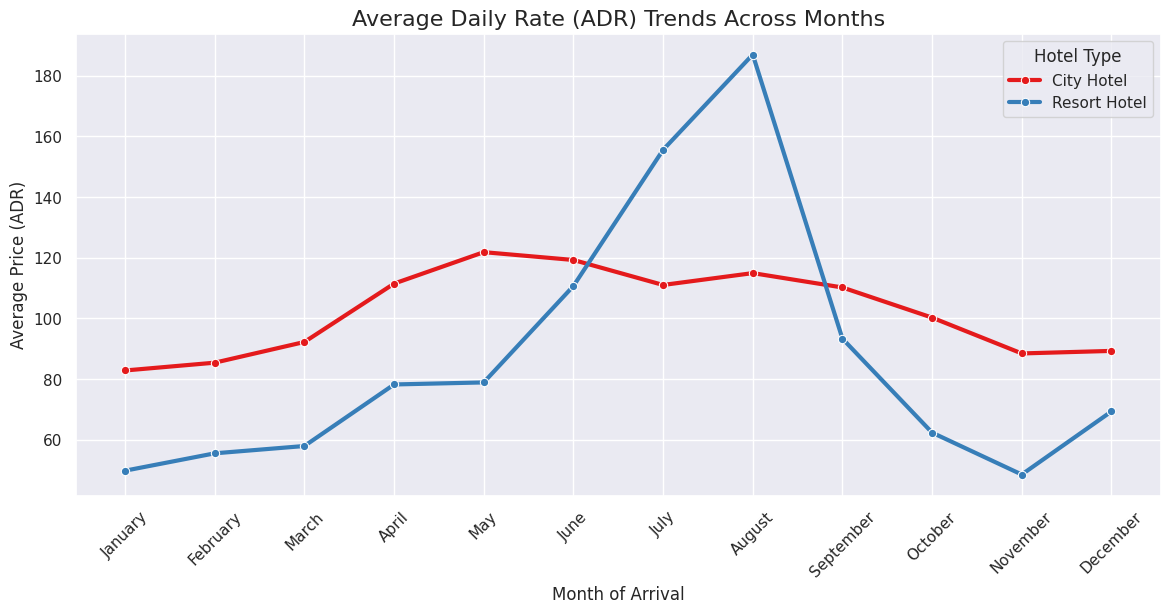

In [ ]:
# Creative Touch: Sort months chronologically, not alphabetically
ordered_months = ["January", "February", "March", "April", "May", "June",
                  "July", "August", "September", "October", "November", "December"]
df_viz['arrival_date_month'] = pd.Categorical(df_viz['arrival_date_month'], categories=ordered_months, ordered=True)

# Calculate monthly average prices
monthly_prices = df_viz.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=monthly_prices,
             marker='o', linewidth=3, palette='Set1')

plt.title('Average Daily Rate (ADR) Trends Across Months', fontsize=16)
plt.xlabel('Month of Arrival', fontsize=12)
plt.ylabel('Average Price (ADR)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.show()

### 2.3 Bar Charts: Grouped and Stacked
**Goal:** Compare cancellations based on deposits (Grouped) and see the market segment breakdown per hotel (Stacked).

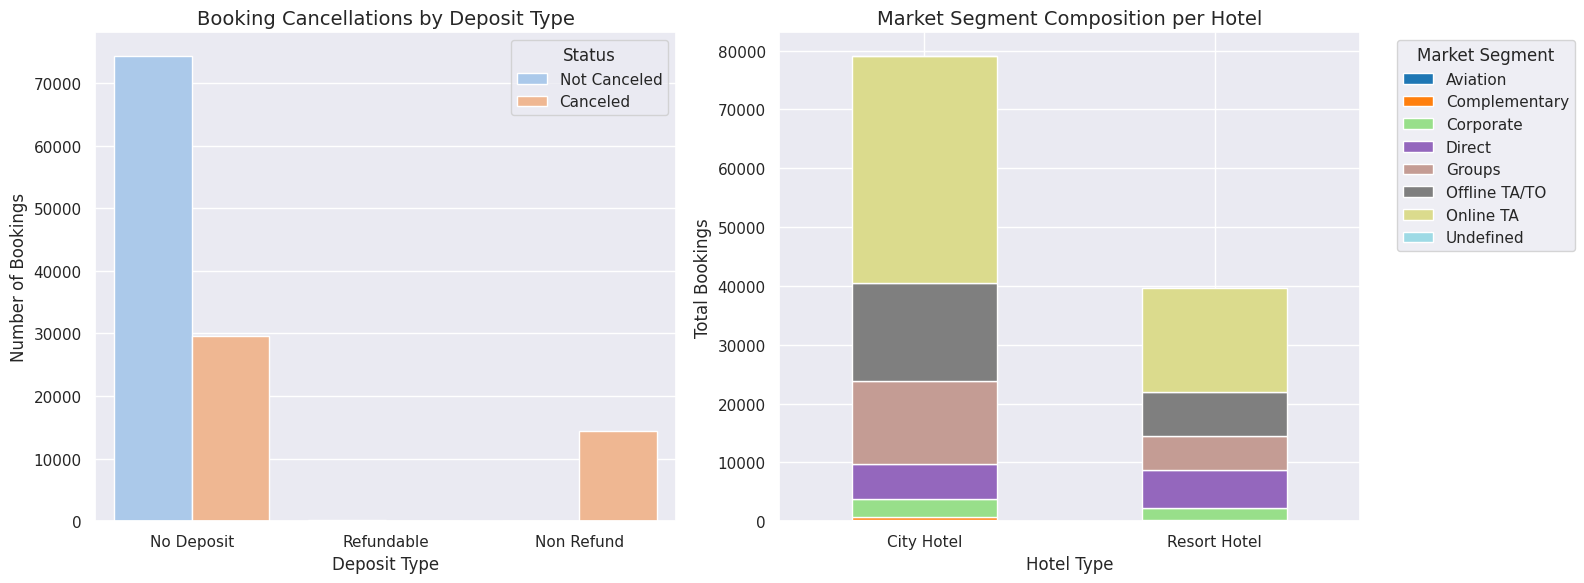

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grouped Bar Chart: Cancellations by Deposit Type
sns.countplot(ax=axes[0], x='deposit_type', hue='is_canceled', data=df_viz, palette='pastel')
axes[0].set_title('Booking Cancellations by Deposit Type', fontsize=14)
axes[0].set_xlabel('Deposit Type', fontsize=12)
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].legend(title='Status', labels=['Not Canceled', 'Canceled'])

# 2. Stacked Bar Chart: Market Segment by Hotel
# Pivot the data for stacked plotting
stacked_data = df_viz.groupby(['hotel', 'market_segment']).size().unstack().fillna(0)
stacked_data.plot(kind='bar', stacked=True, ax=axes[1], cmap='tab20')

axes[1].set_title('Market Segment Composition per Hotel', fontsize=14)
axes[1].set_xlabel('Hotel Type', fontsize=12)
axes[1].set_ylabel('Total Bookings', fontsize=12)
axes[1].legend(title='Market Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 2.4 Scatter Plots and Bubble Charts
**Goal:** Explore the relationship between how early people book (`lead_time`) and the price they pay (`adr`). A bubble chart adds a 3rd dimension: the length of the stay.

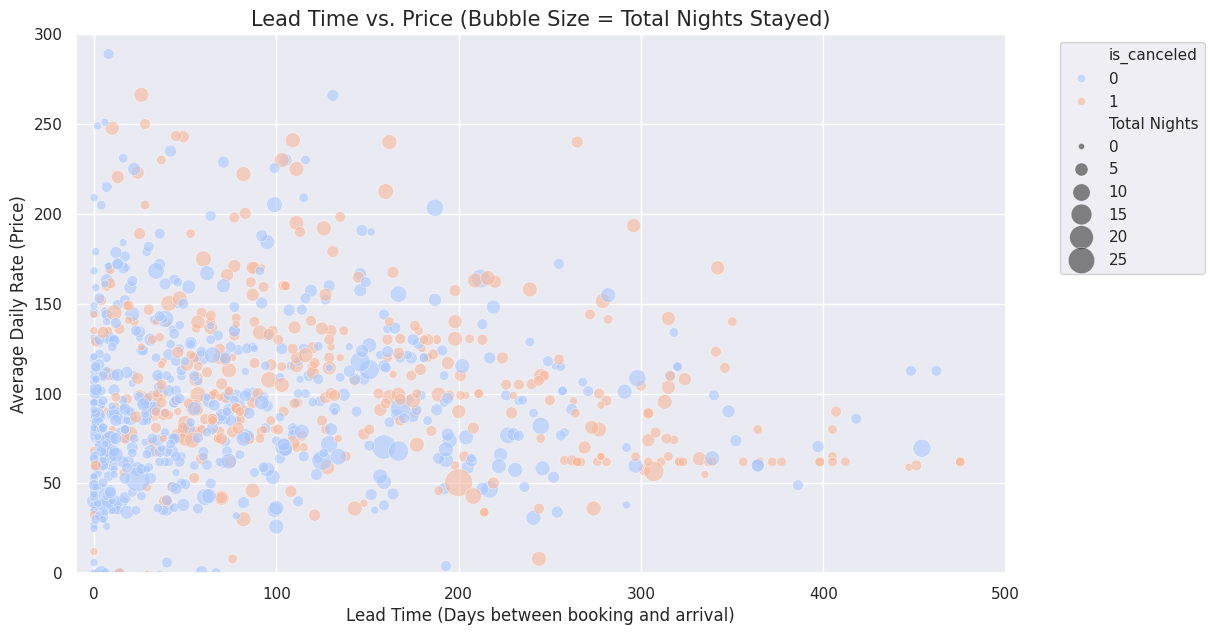

In [ ]:
plt.figure(figsize=(12, 7))

# Take a random sample and create a specific column for the legend
df_sample = df_viz.sample(1000, random_state=42).copy()
df_sample['Total Nights'] = df_sample['stays_in_week_nights'] + df_sample['stays_in_weekend_nights']

# Bubble chart: x=lead_time, y=adr, size=total_nights
sns.scatterplot(x='lead_time', y='adr',
                size='Total Nights',
                sizes=(20, 400), alpha=0.6, hue='is_canceled', palette='coolwarm', data=df_sample)

plt.title('Lead Time vs. Price (Bubble Size = Total Nights Stayed)', fontsize=15)
plt.xlabel('Lead Time (Days between booking and arrival)', fontsize=12)
plt.ylabel('Average Daily Rate (Price)', fontsize=12)
plt.xlim(-10, 500)
plt.ylim(0, 300)

# Clean up the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 2.5 Charts Showing Uncertainty (Error Bars)
**Goal:** Show the average lead time by market segment, including the standard deviation (uncertainty/variance) to see how widely booking behaviors fluctuate.

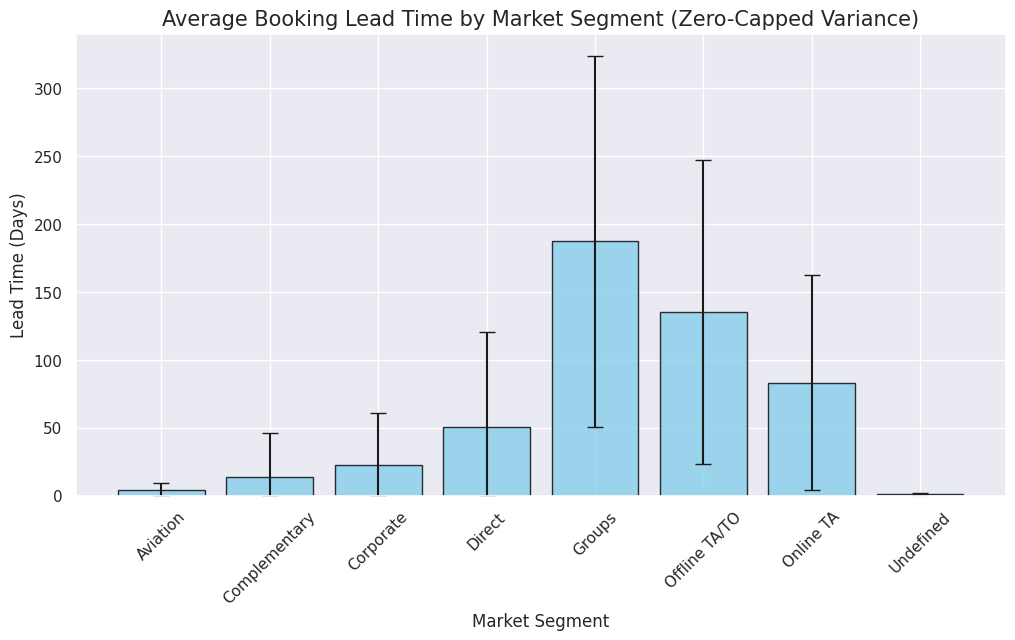

In [ ]:
# Calculate mean and standard deviation
stats = df_viz.groupby('market_segment')['lead_time'].agg(['mean', 'std']).reset_index()
stats.dropna(inplace=True)

# Prevent error bars from dropping below zero (impossible negative lead time)
import numpy as np
lower_error = np.where(stats['mean'] - stats['std'] < 0, stats['mean'], stats['std'])
upper_error = stats['std']
asymmetric_error = [lower_error, upper_error]

plt.figure(figsize=(12, 6))
plt.bar(stats['market_segment'], stats['mean'], yerr=asymmetric_error,
        capsize=6, color='skyblue', edgecolor='black', alpha=0.8)

plt.title('Average Booking Lead Time by Market Segment (Zero-Capped Variance)', fontsize=15)
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Lead Time (Days)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### 2.6 Interactive Charts (Plotly)
**Goal:** Create a modern, interactive visualization where the user can hover over data points to see exact details.

In [ ]:
import plotly.express as px

# We aggregate the data to make the Plotly chart fast and responsive
interactive_df = df_viz.groupby(['arrival_date_month', 'hotel'])[['adr', 'lead_time']].mean().reset_index()

# Create interactive scatter chart
fig = px.scatter(interactive_df,
                 x="lead_time",
                 y="adr",
                 color="hotel",
                 hover_name="arrival_date_month",
                 size="adr",
                 title="Interactive View: Average Lead Time vs ADR per Month",
                 labels={"lead_time": "Average Lead Time (Days)", "adr": "Average Daily Rate ($)"},
                 size_max=30)

fig.update_layout(template="plotly_white", title_font_size=18)
fig.show()

Meaningful Insights from Visualizations

Based on the visual analysis above, we can conclude several key business insights:
1. **Pricing Seasonality:** Resort hotels exhibit massive price volatility, peaking sharply in August (Summer holidays), while City hotel prices remain much more stable year-round.
2. **Cancellation Drivers:** Interestingly, bookings classified as "Non Refund" have a disproportionately high cancellation rate. This anomaly suggests these might be bulk bookings by travel agents that are later dropped.
3. **Booking Behavior:** The bubble chart shows that last-minute bookings (lead time near 0) have the highest price variance, with guests either securing massive discounts or paying high premium rates depending on the hotel's remaining capacity.

### 2.7 Interactive Charts (Bokeh)
**Goal:** Create a granular, interactive time-series chart showing weekly price fluctuations.

**Bonus Feature:** You can hover over the lines to see exact prices, use the tools on the right to zoom in on specific weeks, and **click on the legend items** to mute/hide specific lines!

In [ ]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource, HoverTool

# Initialize Bokeh to display inline in a Google Colab notebook
output_notebook()

# 1. Prepare Data: Average ADR by Week Number
weekly_adr = df_viz.groupby(['arrival_date_week_number', 'hotel'])['adr'].mean().reset_index()
weekly_pivot = weekly_adr.pivot(index='arrival_date_week_number', columns='hotel', values='adr').reset_index()

# 2. Convert to Bokeh DataSource
source = ColumnDataSource(weekly_pivot)

# 3. Create the figure canvas
p = figure(title="Interactive Bokeh: Weekly Average Daily Rate (ADR) Trends",
           x_axis_label="Week of the Year (1 to 53)",
           y_axis_label="Average Daily Rate ($)",
           width=950, height=450,
           tools="pan,wheel_zoom,box_zoom,reset,save")

# 4. Add the lines
p.line(x='arrival_date_week_number', y='City Hotel', source=source,
       color="#E24A33", line_width=3, legend_label="City Hotel")
p.line(x='arrival_date_week_number', y='Resort Hotel', source=source,
       color="#348ABD", line_width=3, legend_label="Resort Hotel")

# 5. Add the interactive Hover Tool
hover = HoverTool()
hover.tooltips = [
    ("Week of Year", "@arrival_date_week_number"),
    ("City Hotel Price", "@{City Hotel}{$0.00}"),
    ("Resort Hotel Price", "@{Resort Hotel}{$0.00}")
]
p.add_tools(hover)

# 6. Customize Legend (Interactive muting)
p.legend.location = "top_left"
p.legend.click_policy = "hide"

# Display the plot
show(p)

Meaningful Insights from Visualizations
Based on the visual analysis above, we can conclude several key business insights:

1. **Extreme Pricing Seasonality:** The interactive Bokeh chart reveals a dramatic difference in pricing strategies. Resort Hotels are highly seasonal, with prices surging to nearly \$200 around **Week 33 (mid-August)** before dropping sharply. Conversely, City Hotel prices are much more stable year-round (hovering between \$80–\$130).
2. **Off-Peak Premium:** Interestingly, the weekly trend line shows that for the vast majority of the year (outside of the peak summer weeks 26 to 36), **City Hotels actually command a higher Average Daily Rate than Resort Hotels**.

# Part 3: Feature Engineering
In this final phase, we will extract deeper insights from our data by creating new features, selecting the most impactful ones using Mutual Information, and reducing the dataset's complexity using Principal Component Analysis (PCA).

### 3.1 Feature Construction and Extraction
First, let's create a fresh copy of our cleaned data so we can engineer new columns based on domain knowledge.

In [ ]:
df_fe = pd.read_csv('hotel_bookings.csv')
df_fe.replace(['NULL', '   NULL'], np.nan, inplace=True)
df_fe['agent'].fillna(0, inplace=True)
df_fe['country'].fillna(df_fe['country'].mode()[0], inplace=True)
df_fe.drop(['company', 'reservation_status'], axis=1, inplace=True) # Drop company (too many NaNs) and status (Data Leakage)
df_fe = df_fe[(df_fe['adults'] + df_fe['children'] + df_fe['babies']) > 0]
df_fe = df_fe[df_fe['adr'] >= 0]
df_fe.dropna(inplace=True)

#### Combinations, Ratios, and Counts
We will combine columns to find the total household size (guests) and the total length of stay. Then, we will create a ratio to find the Price Per Person, and a count of previous booking history.

In [ ]:
# 1. Feature Combinations (Household Size & Total Stay)
df_fe['Total_Guests'] = df_fe['adults'] + df_fe['children'] + df_fe['babies']
df_fe['Total_Nights'] = df_fe['stays_in_weekend_nights'] + df_fe['stays_in_week_nights']

# 2. Ratio (Income/Price per capita)
# We add 0.001 to avoid division by zero errors
df_fe['Price_Per_Person'] = df_fe['adr'] / (df_fe['Total_Guests'] + 0.001)

# 3. Counts
df_fe['Total_Previous_Bookings'] = df_fe['previous_cancellations'] + df_fe['previous_bookings_not_canceled']

df_fe[['adr', 'Total_Guests', 'Price_Per_Person', 'Total_Nights', 'Total_Previous_Bookings']].head()

,adr,Total_Guests,Price_Per_Person,Total_Nights,Total_Previous_Bookings
0,0.0,2.0,0.000000,0,0
1,0.0,2.0,0.000000,0,0
2,75.0,1.0,74.925075,1,0
3,75.0,1.0,74.925075,1,0
4,98.0,2.0,48.975512,2,0


#### Date/Time Transformations
Hotel behavior is highly dependent on *when* people book. Let's convert the arrival year, month, and day into a single Datetime object, and then extract the Day of the Week.

In [ ]:
# Map month names to numbers
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df_fe['arrival_month_num'] = df_fe['arrival_date_month'].map(month_map)

# Create a combined datetime string, then convert to Datetime object
df_fe['Arrival_Date'] = pd.to_datetime(df_fe['arrival_date_year'].astype(str) + '-' +
                                       df_fe['arrival_month_num'].astype(str) + '-' +
                                       df_fe['arrival_date_day_of_month'].astype(str))

# Extract Day of Week (Monday=0, Sunday=6)
df_fe['Arrival_Day_Of_Week'] = df_fe['Arrival_Date'].dt.dayofweek

# Drop the columns we no longer need
df_fe.drop(['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_month_num', 'Arrival_Date'], axis=1, inplace=True)

#### Binning & Mathematical Functions
Just like the lab binned "Recency", we will bin `lead_time` into logical categories. We will also apply a mathematical function (Square Root) to `lead_time` to make its relationship with cancellations more linear.

In [ ]:
# 1. Binning Lead Time
bins = [-1, 7, 30, 90, 365, 1000]
labels = [1, 2, 3, 4, 5] # 1: Last min, 2: Short notice, 3: Planned, 4: Advanced, 5: Very Advanced
df_fe['Binned_Lead_Time'] = pd.cut(df_fe['lead_time'], bins=bins, labels=labels)

# 2. Mathematical Function (Square Root of Lead Time)
# Lead time is highly skewed. A square root transformation reduces extreme outliers.
df_fe['Lead_Time_Func'] = df_fe.apply(lambda x: math.pow(x['lead_time'], 0.5), axis=1)

df_fe[['lead_time', 'Binned_Lead_Time', 'Lead_Time_Func']].head()

,lead_time,Binned_Lead_Time,Lead_Time_Func
0,342,4,18.493242
1,737,5,27.147744
2,7,1,2.645751
3,13,2,3.605551
4,14,2,3.741657


#### Aggregation (Target Encoding / Group Means)
Following the lab's example, we will compare the ADR (Price) of a specific booking to the average ADR of its respective Market Segment.

In [ ]:
# Calculate the mean ADR for each market segment
df_fe['Avg_ADR_Market_Segment'] = df_fe['adr'].groupby(df_fe['market_segment']).transform('mean')

# Calculate the ratio of this booking's price compared to the segment average
df_fe['ADR_to_Segment_Ratio'] = df_fe['adr'] / (df_fe['Avg_ADR_Market_Segment'] + 0.001)

df_fe[['market_segment', 'adr', 'Avg_ADR_Market_Segment', 'ADR_to_Segment_Ratio']].head()

,market_segment,adr,Avg_ADR_Market_Segment,ADR_to_Segment_Ratio
0,Direct,0.0,115.642833,0.000000
1,Direct,0.0,115.642833,0.000000
2,Direct,75.0,115.642833,0.648543
3,Corporate,75.0,69.528332,1.078681
4,Online TA,98.0,117.318746,0.835324


### 3.2 Feature Selection (Mutual Information)
Now we will use Mutual Information to see which features carry the most weight when predicting our target variable (`is_canceled`).

**Note:** Because our target variable is discrete/binary (0 or 1), we will use `mutual_info_classif` instead of `mutual_info_regression`.

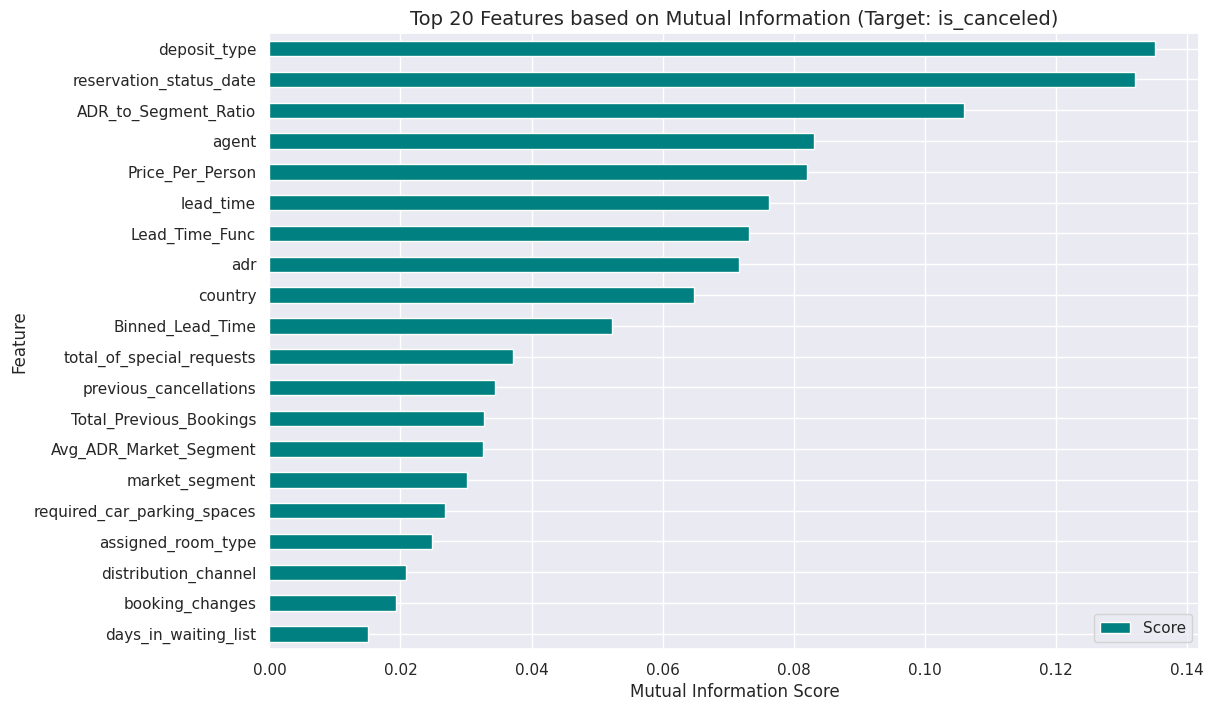

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 1. Convert all categorical values to numerical (Factorize)
for colname in df_fe.select_dtypes(["object", "category"]):
    df_fe[colname], _ = df_fe[colname].factorize()

df_fe = df_fe.dropna(axis=0)

# 2. Pop the target column
target_column = df_fe.pop("is_canceled")

# 3. Run Mutual Information (Using a sample of 15,000 rows for computational efficiency)
sample_size = 15000
df_sample = df_fe.sample(sample_size, random_state=42)
target_sample = target_column.loc[df_sample.index]

# Fit selector
feature_selector = SelectKBest(score_func=mutual_info_classif, k='all').fit(df_sample, target_sample)
feature_scores = pd.DataFrame({'Feature': df_fe.columns, 'Score': feature_selector.scores_})
feature_scores.sort_values(by=['Score'], ascending=True, inplace=True)

# 4. Plot the Top 20 Features
feature_scores[-20:].plot(x='Feature', y='Score', kind='barh', figsize=(12, 8), color='teal')
plt.title('Top 20 Features based on Mutual Information (Target: is_canceled)', fontsize=14)
plt.xlabel('Mutual Information Score')
plt.show()

### 3.3 Principal Component Analysis (PCA)
With all these new features, our dataset is quite wide. We will standardize our data and apply PCA to see how many principal components are required to explain the variance in our data.

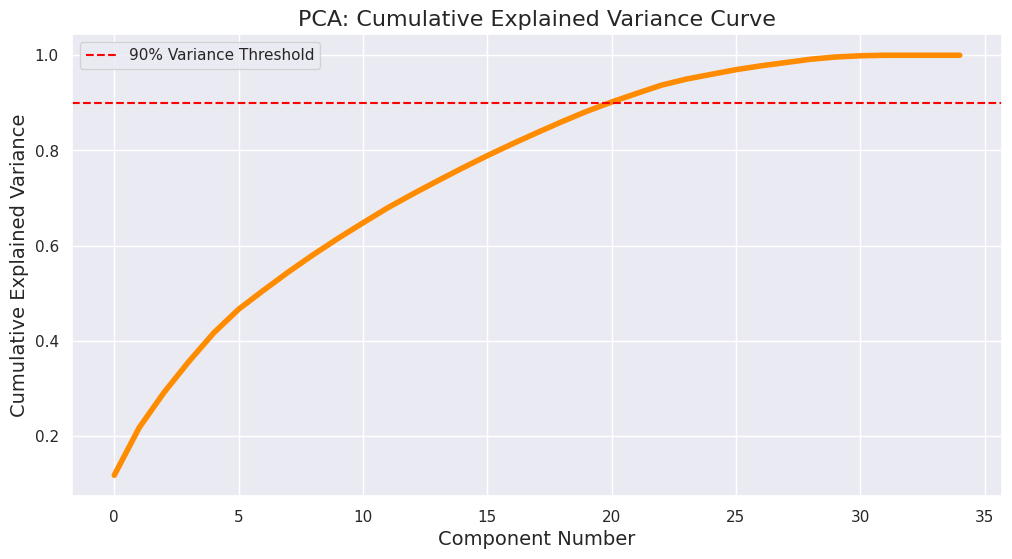

Original Number of Features: 35
Number of PCA Components keeping 90% of variance: 21


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure

# 1. Standardize the data
normalized_df = StandardScaler().fit_transform(df_fe)

# 2. Fit PCA (Using all components to see the variance curve)
pca = PCA()
principalComponents = pca.fit_transform(normalized_df)

# 3. Plot Cumulative Explained Variance
figure(figsize=(12, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), lw=4, color='darkorange')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Variance Threshold')

plt.xlabel('Component Number', fontsize=14)
plt.ylabel('Cumulative Explained Variance', fontsize=14)
plt.title('PCA: Cumulative Explained Variance Curve', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# 4. Apply final PCA keeping 90% of the variance
pca_final = PCA(n_components=0.90)
df_pca_final = pca_final.fit_transform(normalized_df)

print(f"Original Number of Features: {normalized_df.shape[1]}")
print(f"Number of PCA Components keeping 90% of variance: {df_pca_final.shape[1]}")

---
### 3.4 Reflective Question

**“When is feature engineering a nice-to-have option, and when is it a must-have?”**

**Answer:**
Feature engineering is a **must-have** in two primary scenarios:
1. When dealing with raw data types that machine learning algorithms cannot inherently process, such as dates (which must be split into days, months, and years) or raw text.
2. When using traditional, linear machine learning models (like Logistic Regression or standard Linear Regression). These models cannot learn complex, non-linear interactions on their own, so we *must* engineer mathematical functions (like square roots) or manual combinations (like `total_guests = adults + children`) to expose those relationships to the model.

Feature engineering is a **nice-to-have option** when utilizing highly advanced algorithms, such as Deep Learning (Neural Networks) or complex Tree-Based Ensembles (like XGBoost or Random Forests). Because these models are mathematically designed to automatically detect interactions, non-linear relationships, and thresholds (like natural binning), they can often achieve high accuracy with relatively raw data. However, even with advanced models, doing *some* feature engineering is nice to have because it can drastically speed up training times and make the model's decisions more interpretable to humans.